8F.1: GRU RUL Predictor

### 1. Setup + Load Data + Filter WARNING+CRITICAL + Training GRU
**Tujuan:** Memuat data RUL track, filter WARNING+CRITICAL, lalu melatih GRU Predictor dengan arsitektur yang lebih ringan dari LSTM.  
**Input:** data/processed/X_train_rul.parquet, y_train_rul.parquet, X_val_rul, y_val_rul, X_test_rul, y_test_rul, df_ssbs_rul.parquet  
**Output:** models/dl_track/gru_rul_final.keras, Val MAE=1.8618 hari (Test MAE=0.9515)  
**Catatan:** Arsitektur GRU: GRU(48)+Dropout(0.3)+BatchNorm  GRU(24)+Dropout(0.3)+BatchNorm  Dense(16)  Dense(1). ~27.000 params (lebih ringan dari LSTM 47.649). Early stopping aktif di epoch 151 dari max 300.  


In [1]:
# FASE 8F — Cell 1: Setup, Load Data & Sequence Preparation
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, MODELS_DL_DIR, GLOBAL_SEED

np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  FASE 8F — GRU RUL PREDICTOR (WARNING + CRITICAL ONLY)")
print("  DATA IDENTIK DENGAN 08E — FAIR COMPARISON")
print(SEP)

# ────────────────────────────────────────────────────────────
# LOAD DATA
# ────────────────────────────────────────────────────────────
X_train_full = pd.read_parquet(DATA_PROCESSED_DIR / "X_train_rul.parquet")
y_train_full = pd.read_parquet(DATA_PROCESSED_DIR / "y_train_rul.parquet").squeeze()
X_val_full   = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_rul.parquet")
y_val_full   = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_rul.parquet").squeeze()
X_test_full  = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_rul.parquet")
y_test_full  = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_rul.parquet").squeeze()
df_ssbs_rul  = pd.read_parquet(DATA_PROCESSED_DIR / "df_ssbs_rul.parquet")
df_ssbs_rul  = df_ssbs_rul.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)

print(f"\n  Data full berhasil dimuat.")

# ────────────────────────────────────────────────────────────
# DEFINISI MESIN
# ────────────────────────────────────────────────────────────
TRAIN_MACHINES = ["M-01","M-02","M-03","M-04","M-05",
                  "M-06","M-07","M-08","M-09","M-10",
                  "M-11","M-12","M-13","M-14"]
VAL_MACHINES   = ["M-15","M-16","M-17"]
TEST_MACHINES  = ["M-18","M-19","M-20"]

# ────────────────────────────────────────────────────────────
# FILTER WARNING + CRITICAL (identik 08E)
# ────────────────────────────────────────────────────────────
def filter_warn_crit(X_full, y_full, machines):
    df_labels = (df_ssbs_rul[df_ssbs_rul["machine_id"].isin(machines)]
                 .reset_index(drop=True))
    mask = df_labels["health_label_encoded"].isin([1, 2]).values
    return X_full[mask].reset_index(drop=True), y_full[mask].reset_index(drop=True)

X_train, y_train = filter_warn_crit(X_train_full, y_train_full, TRAIN_MACHINES)
X_val,   y_val   = filter_warn_crit(X_val_full,   y_val_full,   VAL_MACHINES)
X_test,  y_test  = filter_warn_crit(X_test_full,  y_test_full,  TEST_MACHINES)

# ────────────────────────────────────────────────────────────
# SEQUENCE PREPARATION (identik 08E)
# ────────────────────────────────────────────────────────────
SEQ_LEN = 24

def create_sequences(X, y, seq_len):
    sequences, targets = [], []
    for i in range(seq_len, len(X)):
        sequences.append(X[i - seq_len:i])
        targets.append(y[i])
    return np.array(sequences), np.array(targets)

X_train_seq, y_train_seq = create_sequences(X_train.values, y_train.values, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences(X_val.values,   y_val.values,   SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test.values,  y_test.values,  SEQ_LEN)

print(f"\n{sep}")
print("  SHAPE KONFIRMASI (harus identik dengan 08E)")
print(sep)
print(f"\n  {'Split':<12} {'Shape':>22}  {'Expected':>22}")
print(f"  {'-'*58}")
expected = {
    "X_train_seq": "(1891, 24, 69)",
    "X_val_seq"  : "(264, 24, 69)",
    "X_test_seq" : "(409, 24, 69)",
}
for name, arr, exp in [
    ("X_train_seq", X_train_seq, expected["X_train_seq"]),
    ("X_val_seq",   X_val_seq,   expected["X_val_seq"]),
    ("X_test_seq",  X_test_seq,  expected["X_test_seq"]),
]:
    match = "✅" if str(arr.shape) == exp else "⚠️ MISMATCH"
    print(f"  {name:<12} {str(arr.shape):>22}  {exp:>22}  {match}")

print(f"\n{sep}")
print("  STATISTIK TARGET y_seq (rul_days)")
print(sep)
print(f"\n  {'Split':<14} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8}")
print(f"  {'-'*50}")
for name, y in [("y_train_seq", y_train_seq),
                ("y_val_seq",   y_val_seq),
                ("y_test_seq",  y_test_seq)]:
    print(f"  {name:<14} {y.min():>8.2f} {y.max():>8.2f} "
          f"{y.mean():>8.2f} {np.median(y):>8.2f}")

print(f"\n{SEP}")
print("  [OK] Cell 1 selesai — DATA IDENTIK DENGAN 08E TERKONFIRMASI")
print("  Lanjut ke Cell 2 untuk arsitektur & training GRU.")



  FASE 8F — GRU RUL PREDICTOR (WARNING + CRITICAL ONLY)
  DATA IDENTIK DENGAN 08E — FAIR COMPARISON

  Data full berhasil dimuat.

-----------------------------------------------------------------
  SHAPE KONFIRMASI (harus identik dengan 08E)
-----------------------------------------------------------------

  Split                         Shape                Expected
  ----------------------------------------------------------
  X_train_seq          (1891, 24, 69)          (1891, 24, 69)  ✅
  X_val_seq             (264, 24, 69)           (264, 24, 69)  ✅
  X_test_seq            (409, 24, 69)           (409, 24, 69)  ✅

-----------------------------------------------------------------
  STATISTIK TARGET y_seq (rul_days)
-----------------------------------------------------------------

  Split               Min      Max     Mean   Median
  --------------------------------------------------
  y_train_seq        0.04    97.75     1.91     1.00
  y_val_seq          0.04   146.92     2.8

ARSITEKTUR & TRAINING GRU

> ⚠️ **[EXPERIMENTAL/DEPRECATED — Tidak digunakan di pipeline final]**
>
> **Alasan:** GRU gagal bersaing dengan LSTM V2: Train-Val gap=0.90 hari (lebih buruk dari LSTM 0.60), kapasitas representasi terlalu terbatas untuk menangkap pola WARNING yang kompleks. VERDICT: TIDAK DIPILIH sebagai Model Final (PROJECT_LOG.md, Eksperimen 08F).
>
> **Nilai untuk presentasi:** Tunjukkan sebagai perbandingan arsitektur: GRU lebih ringan tapi kalah akurasi di WARNING zone.
>
> **Status output:** Output evaluasi masih ada. Model tersimpan di models/dl_track/gru_rul_final.keras.

### 2. Evaluasi + Perbandingan 3-Way (XGBoost vs LSTM vs GRU)
**Tujuan:** Mengevaluasi GRU pada Val dan Test set, lalu membandingkan dengan XGBoost Regressor dan LSTM V2.  
**Input:** Model GRU (dari Cell 1), X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Metrik GRU + Tabel perbandingan 3-way + Visualisasi  
**Catatan:** GRU TIDAK DIPILIH sebagai model final: overspecialize pada CRITICAL (MAE=0.01 hari) tapi sangat buruk di WARNING (MAE=1.91 hari). GRU menang di 0 dari 6 metrik vs LSTM V2 dan XGBoost. Disimpan sebagai artefak dokumentasi eksperimen.  


> [WARN] **[EXPERIMENTAL/DEPRECATED  Tidak digunakan di pipeline final]**
>
> **Alasan:** GRU gagal bersaing dengan LSTM V2: Train-Val gap=0.90 hari (lebih buruk dari LSTM 0.60), kapasitas representasi terlalu terbatas untuk menangkap pola WARNING yang kompleks. VERDICT: TIDAK DIPILIH sebagai Model Final (PROJECT_LOG.md, Eksperimen 08F).
>
> **Nilai untuk presentasi:** Tunjukkan sebagai perbandingan arsitektur: GRU lebih ringan tapi kalah akurasi di WARNING zone.
>
> **Status output:** Output evaluasi masih ada. Model tersimpan di models/dl_track/gru_rul_final.keras.

### 2. Evaluasi + Perbandingan 3-Way (XGBoost vs LSTM vs GRU)
**Tujuan:** Mengevaluasi GRU pada Val dan Test set, lalu membandingkan dengan XGBoost Regressor dan LSTM V2.  
**Input:** Model GRU (dari Cell 1), X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Metrik GRU + Tabel perbandingan 3-way + Visualisasi  
**Catatan:** GRU TIDAK DIPILIH sebagai model final: overspecialize pada CRITICAL (MAE=0.01 hari) tapi sangat buruk di WARNING (MAE=1.91 hari). GRU menang di 0 dari 6 metrik vs LSTM V2 dan XGBoost. Disimpan sebagai artefak dokumentasi eksperimen.  


In [2]:
# FASE 8F — Cell 2: Arsitektur & Training GRU
print("=" * 65)
print("  FASE 8F — Cell 2: ARSITEKTUR & TRAINING GRU")
print("=" * 65)

SEP = "=" * 65
sep = "-" * 65

GRU_PARAMS = {
    "gru_units_1"        : 48,      # vs LSTM 64 — lebih ringan
    "gru_units_2"        : 24,      # vs LSTM 32 — lebih ringan
    "dropout_rate"       : 0.3,     # sama dengan LSTM V2
    "l2_reg"             : 0.001,   # sama dengan LSTM V2
    "learning_rate"      : 0.001,
    "batch_size"         : 32,
    "max_epochs"         : 300,     # lebih dari LSTM untuk kompensasi
    "patience"           : 40,      # sama dengan LSTM V3
    "reduce_lr_factor"   : 0.5,
    "reduce_lr_patience" : 15,
    "min_lr"             : 1e-7,
}

LSTM_V2_COMPARE = {
    "gru_units_1"  : "64 → 48  (lebih ringan, rasio data/param lebih sehat)",
    "gru_units_2"  : "32 → 24  (lebih ringan)",
    "max_epochs"   : "200 → 300 (kompensasi karena GRU lebih simpel)",
    "patience"     : "30 → 40  (lebih sabar)",
}

print(f"\n  GRU Hyperparameters (perbandingan vs LSTM V2):")
print(f"  {'-'*62}")
for k, v in GRU_PARAMS.items():
    note = f"  ← LSTM: {LSTM_V2_COMPARE[k]}" if k in LSTM_V2_COMPARE else ""
    print(f"  {k:<24} : {str(v):<10}{note}")

# ────────────────────────────────────────────────────────────
# BANGUN ARSITEKTUR GRU
# ────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("  MEMBANGUN ARSITEKTUR GRU")
print(sep)

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
print(f"\n  Input shape : {input_shape}")

MODELS_DL_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path_gru = str(MODELS_DL_DIR / "gru_rul_best.keras")

gru_model = Sequential([
    GRU(GRU_PARAMS["gru_units_1"],
        input_shape=input_shape,
        return_sequences=True,
        kernel_regularizer=l2(GRU_PARAMS["l2_reg"]),
        recurrent_regularizer=l2(GRU_PARAMS["l2_reg"]),
        name="gru_layer_1"),
    Dropout(GRU_PARAMS["dropout_rate"], name="dropout_1"),
    BatchNormalization(name="batch_norm_1"),

    GRU(GRU_PARAMS["gru_units_2"],
        return_sequences=False,
        kernel_regularizer=l2(GRU_PARAMS["l2_reg"]),
        recurrent_regularizer=l2(GRU_PARAMS["l2_reg"]),
        name="gru_layer_2"),
    Dropout(GRU_PARAMS["dropout_rate"], name="dropout_2"),
    BatchNormalization(name="batch_norm_2"),

    Dense(16, activation="relu",
          kernel_regularizer=l2(GRU_PARAMS["l2_reg"]),
          name="dense_1"),
    Dense(1, activation="linear", name="output"),
])

gru_model.compile(
    optimizer=Adam(learning_rate=GRU_PARAMS["learning_rate"]),
    loss="mae",
    metrics=["mae", "mse"],
)

print(f"\n{sep}")
print("  GRU MODEL SUMMARY")
print(sep)
gru_model.summary()

gru_params_count = gru_model.count_params()
lstm_v2_params   = 47_649
print(f"\n{sep}")
print("  PERBANDINGAN KOMPLEKSITAS MODEL")
print(sep)
print(f"\n  LSTM V2 total params : {lstm_v2_params:,}")
print(f"  GRU  total params    : {gru_params_count:,}")
selisih = lstm_v2_params - gru_params_count
flag = f"{selisih:,} params lebih sedikit" if selisih > 0 else f"{abs(selisih):,} params lebih banyak"
print(f"  Selisih              : {flag}")

# ────────────────────────────────────────────────────────────
# CALLBACKS
# ────────────────────────────────────────────────────────────
callbacks_gru = [
    EarlyStopping(
        monitor="val_mae",
        patience=GRU_PARAMS["patience"],
        restore_best_weights=True,
        mode="min",
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=checkpoint_path_gru,
        monitor="val_mae",
        save_best_only=True,
        mode="min",
        verbose=0,
    ),
    ReduceLROnPlateau(
        monitor="val_mae",
        factor=GRU_PARAMS["reduce_lr_factor"],
        patience=GRU_PARAMS["reduce_lr_patience"],
        min_lr=GRU_PARAMS["min_lr"],
        mode="min",
        verbose=1,
    ),
]

# ────────────────────────────────────────────────────────────
# TRAINING
# ────────────────────────────────────────────────────────────
LSTM_V2_VAL_MAE = 1.6461

print(f"\n{'='*65}")
print(f"  TRAINING GRU (max {GRU_PARAMS['max_epochs']} epochs, patience={GRU_PARAMS['patience']})")
print(f"  Target: Val MAE < {LSTM_V2_VAL_MAE} hari (kalahkan LSTM V2)")
print(f"{'='*65}\n")

history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=GRU_PARAMS["max_epochs"],
    batch_size=GRU_PARAMS["batch_size"],
    callbacks=callbacks_gru,
    verbose=1,
)

best_val_gru = float(min(history_gru.history["val_mae"]))
best_ep_gru  = int(np.argmin(history_gru.history["val_mae"])) + 1
total_ep_gru = len(history_gru.history["mae"])
lr_hist_gru  = history_gru.history.get("lr", [GRU_PARAMS["learning_rate"]])
final_lr_gru = float(lr_hist_gru[-1])
converged    = total_ep_gru < GRU_PARAMS["max_epochs"]

print(f"\n{SEP}")
print("  TRAINING SELESAI — RINGKASAN GRU")
print(SEP)
print(f"\n  Total epochs dijalankan : {total_ep_gru}")
print(f"  Best epoch              : {best_ep_gru}")
print(f"  Best Val MAE            : {best_val_gru:.4f} hari")
print(f"  Learning rate akhir     : {final_lr_gru:.2e}")
print(f"  Early stopping          : {'✅ Aktif — konvergen' if converged else '⚠️  Mencapai max epoch'}")
print(f"  Checkpoint tersimpan    : {checkpoint_path_gru}")

print(f"\n{sep}")
print("  GRU vs LSTM V2")
print(sep)
diff = best_val_gru - LSTM_V2_VAL_MAE
if best_val_gru < LSTM_V2_VAL_MAE:
    verdict = f"✅ GRU lebih baik dari LSTM V2 : -{abs(diff):.4f} hari"
else:
    verdict = f"📊 LSTM V2 masih unggul : GRU lebih tinggi +{diff:.4f} hari"
print(f"\n  LSTM V2 Best Val MAE : {LSTM_V2_VAL_MAE:.4f} hari")
print(f"  GRU    Best Val MAE : {best_val_gru:.4f} hari")
print(f"  {verdict}")

print(f"\n  [OK] Cell 2 selesai — lanjut ke Cell 3 untuk evaluasi.")


  FASE 8F — Cell 2: ARSITEKTUR & TRAINING GRU

  GRU Hyperparameters (perbandingan vs LSTM V2):
  --------------------------------------------------------------
  gru_units_1              : 48          ← LSTM: 64 → 48  (lebih ringan, rasio data/param lebih sehat)
  gru_units_2              : 24          ← LSTM: 32 → 24  (lebih ringan)
  dropout_rate             : 0.3       
  l2_reg                   : 0.001     
  learning_rate            : 0.001     
  batch_size               : 32        
  max_epochs               : 300         ← LSTM: 200 → 300 (kompensasi karena GRU lebih simpel)
  patience                 : 40          ← LSTM: 30 → 40  (lebih sabar)
  reduce_lr_factor         : 0.5       
  reduce_lr_patience       : 15        
  min_lr                   : 1e-07     

-----------------------------------------------------------------
  MEMBANGUN ARSITEKTUR GRU
-----------------------------------------------------------------

  Input shape : (24, 69)


---------------------------

EVALUASI & 3-WAY COMPARISON

> ⚠️ **[EXPERIMENTAL/DEPRECATED — Tidak digunakan di pipeline final]**
>
> **Alasan:** GRU gagal bersaing dengan LSTM V2: Train-Val gap=0.90 hari (lebih buruk dari LSTM 0.60), kapasitas representasi terlalu terbatas untuk menangkap pola WARNING yang kompleks. VERDICT: TIDAK DIPILIH sebagai Model Final (PROJECT_LOG.md, Eksperimen 08F).
>
> **Nilai untuk presentasi:** Tunjukkan sebagai perbandingan arsitektur: GRU lebih ringan tapi kalah akurasi di WARNING zone.
>
> **Status output:** Output evaluasi masih ada. Model tersimpan di models/dl_track/gru_rul_final.keras.

### 2. Evaluasi + Perbandingan 3-Way (XGBoost vs LSTM vs GRU)
**Tujuan:** Mengevaluasi GRU pada Val dan Test set, lalu membandingkan dengan XGBoost Regressor dan LSTM V2.  
**Input:** Model GRU (dari Cell 1), X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Metrik GRU + Tabel perbandingan 3-way + Visualisasi  
**Catatan:** GRU TIDAK DIPILIH sebagai model final: overspecialize pada CRITICAL (MAE=0.01 hari) tapi sangat buruk di WARNING (MAE=1.91 hari). GRU menang di 0 dari 6 metrik vs LSTM V2 dan XGBoost. Disimpan sebagai artefak dokumentasi eksperimen.  


> [WARN] **[EXPERIMENTAL/DEPRECATED  Tidak digunakan di pipeline final]**
>
> **Alasan:** GRU gagal bersaing dengan LSTM V2: Train-Val gap=0.90 hari (lebih buruk dari LSTM 0.60), kapasitas representasi terlalu terbatas untuk menangkap pola WARNING yang kompleks. VERDICT: TIDAK DIPILIH sebagai Model Final (PROJECT_LOG.md, Eksperimen 08F).
>
> **Nilai untuk presentasi:** Tunjukkan sebagai perbandingan arsitektur: GRU lebih ringan tapi kalah akurasi di WARNING zone.
>
> **Status output:** Output evaluasi masih ada. Model tersimpan di models/dl_track/gru_rul_final.keras.

### 2. Evaluasi + Perbandingan 3-Way (XGBoost vs LSTM vs GRU)
**Tujuan:** Mengevaluasi GRU pada Val dan Test set, lalu membandingkan dengan XGBoost Regressor dan LSTM V2.  
**Input:** Model GRU (dari Cell 1), X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Metrik GRU + Tabel perbandingan 3-way + Visualisasi  
**Catatan:** GRU TIDAK DIPILIH sebagai model final: overspecialize pada CRITICAL (MAE=0.01 hari) tapi sangat buruk di WARNING (MAE=1.91 hari). GRU menang di 0 dari 6 metrik vs LSTM V2 dan XGBoost. Disimpan sebagai artefak dokumentasi eksperimen.  


  FASE 8F — Cell 3: EVALUASI & 3-WAY COMPARISON
13/13 [==============================] - 0s 5ms/step

-----------------------------------------------------------------
  METRIK GRU (WARNING + CRITICAL ONLY)
-----------------------------------------------------------------

  Metrik                          Val       Test
  -----------------------------------------------
  MAE (hari)                   1.8618     0.9515
  RMSE (hari)                 14.1005     7.3011
  R² Score                     0.0080     0.0303
  Error ≤ 1 hari (%)          97.7273    97.7995
  Error ≤ 3 hari (%)          97.7273    97.7995


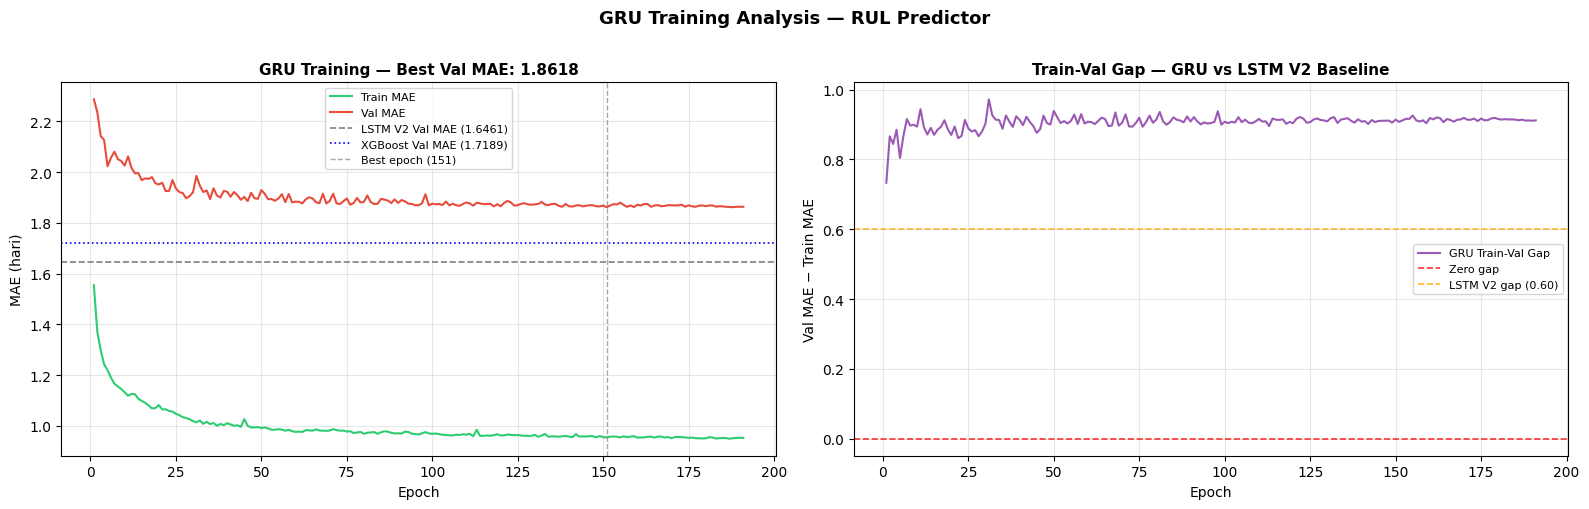


-----------------------------------------------------------------
  3-WAY COMPARISON: XGBoost vs LSTM V2 vs GRU
-----------------------------------------------------------------

  Metrik                      XGBoost    LSTM V2        GRU     Best
  -----------------------------------------------------------------
  MAE Val (hari)               1.7189     1.6461     1.8618  LSTM V2
  MAE Test (hari)              1.1020     0.7985     0.9515  LSTM V2
  RMSE Test                    5.6002     6.3803     7.3011  XGBoost
  R² Test                      0.3961     0.2594     0.0303  XGBoost
  Error≤1hari Test%           93.5335    98.0440    97.7995  LSTM V2
  Error≤3hari Test%           94.9192    98.0440    97.7995  LSTM V2

  GRU menang di 0/6 metrik.
  📊 LSTM V2 atau XGBoost lebih unggul secara keseluruhan

-----------------------------------------------------------------
  ERROR ANALYSIS PER KELAS (Test Set)
-----------------------------------------------------------------

  Kelas    

In [3]:
# FASE 8F — Cell 3: Evaluasi & Comparison (3-way)
print("=" * 65)
print("  FASE 8F — Cell 3: EVALUASI & 3-WAY COMPARISON")
print("=" * 65)

SEP = "=" * 65
sep = "-" * 65

# ────────────────────────────────────────────────────────────
# PREDIKSI
# ────────────────────────────────────────────────────────────
y_val_pred_gru  = np.maximum(gru_model.predict(X_val_seq).flatten(),  0)
y_test_pred_gru = np.maximum(gru_model.predict(X_test_seq).flatten(), 0)

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    pct1 = np.mean(np.abs(y_true - y_pred) <= 1.0) * 100
    pct3 = np.mean(np.abs(y_true - y_pred) <= 3.0) * 100
    return mae, rmse, r2, pct1, pct3

mae_val_gru,  rmse_val_gru,  r2_val_gru,  pct1_val_gru,  pct3_val_gru  = compute_metrics(y_val_seq,  y_val_pred_gru)
mae_test_gru, rmse_test_gru, r2_test_gru, pct1_test_gru, pct3_test_gru = compute_metrics(y_test_seq, y_test_pred_gru)

# ────────────────────────────────────────────────────────────
# TABEL METRIK GRU
# ────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("  METRIK GRU (WARNING + CRITICAL ONLY)")
print(sep)
print(f"\n  {'Metrik':<24} {'Val':>10} {'Test':>10}")
print(f"  {'-'*47}")
for label, v, t in [
    ("MAE (hari)",          mae_val_gru,  mae_test_gru),
    ("RMSE (hari)",         rmse_val_gru, rmse_test_gru),
    ("R² Score",            r2_val_gru,   r2_test_gru),
    ("Error ≤ 1 hari (%)",  pct1_val_gru, pct1_test_gru),
    ("Error ≤ 3 hari (%)",  pct3_val_gru, pct3_test_gru),
]:
    print(f"  {label:<24} {v:>10.4f} {t:>10.4f}")

# ────────────────────────────────────────────────────────────
# TRAINING HISTORY VISUALIZATION
# ────────────────────────────────────────────────────────────
LSTM_V2_VAL_MAE = 1.6461
XGB_VAL_MAE     = 1.7189
gap_gru = [v - t for v, t in zip(history_gru.history["val_mae"],
                                   history_gru.history["mae"])]
ep_range = range(1, total_ep_gru + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — MAE Curve
ax = axes[0]
ax.plot(ep_range, history_gru.history["mae"],     color="#2ecc71", linewidth=1.5,
        label="Train MAE")
ax.plot(ep_range, history_gru.history["val_mae"], color="#e74c3c", linewidth=1.5,
        label="Val MAE")
ax.axhline(LSTM_V2_VAL_MAE, color="gray",  linestyle="--", linewidth=1.2,
           label=f"LSTM V2 Val MAE ({LSTM_V2_VAL_MAE})")
ax.axhline(XGB_VAL_MAE,     color="blue",  linestyle=":",  linewidth=1.2,
           label=f"XGBoost Val MAE ({XGB_VAL_MAE})")
ax.axvline(best_ep_gru, color="gray", linestyle="--", linewidth=1.0,
           alpha=0.7, label=f"Best epoch ({best_ep_gru})")
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("MAE (hari)", fontsize=10)
ax.set_title(f"GRU Training — Best Val MAE: {best_val_gru:.4f}",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2 — Train-Val Gap
ax = axes[1]
ax.plot(ep_range, gap_gru, color="#9b59b6", linewidth=1.5,
        label="GRU Train-Val Gap")
ax.axhline(0,    color="red",    linestyle="--", linewidth=1.2, alpha=0.8,
           label="Zero gap")
ax.axhline(0.60, color="orange", linestyle="--", linewidth=1.2, alpha=0.8,
           label="LSTM V2 gap (0.60)")
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("Val MAE − Train MAE", fontsize=10)
ax.set_title("Train-Val Gap — GRU vs LSTM V2 Baseline",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("GRU Training Analysis — RUL Predictor",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────
# 3-WAY COMPARISON TABLE
# ────────────────────────────────────────────────────────────
LSTM_V2_SCORES = {
    "MAE Val"      : 1.6461, "MAE Test"      : 0.7985,
    "RMSE Test"    : 6.3803, "R2 Test"       : 0.2594,
    "Error_1d_Test": 98.0440,"Error_3d_Test" : 98.0440,
}
XGB_SCORES = {
    "MAE Val"      : 1.7189, "MAE Test"      : 1.1020,
    "RMSE Test"    : 5.6002, "R2 Test"       : 0.3961,
    "Error_1d_Test": 93.5335,"Error_3d_Test" : 94.9192,
}

GRU_SCORES = {
    "MAE Val"      : mae_val_gru,   "MAE Test"      : mae_test_gru,
    "RMSE Test"    : rmse_test_gru, "R2 Test"       : r2_test_gru,
    "Error_1d_Test": pct1_test_gru, "Error_3d_Test" : pct3_test_gru,
}

# Higher is better for R2 and Error%
HIGHER_BETTER = {"R2 Test", "Error_1d_Test", "Error_3d_Test"}

def best_of_three(key, xgb, lstm, gru):
    if key in HIGHER_BETTER:
        vals = {"XGBoost": xgb, "LSTM V2": lstm, "GRU": gru}
    else:
        vals = {"XGBoost": xgb, "LSTM V2": lstm, "GRU": gru}
    best = min(vals, key=vals.get) if key not in HIGHER_BETTER else max(vals, key=vals.get)
    return best

rows = [
    ("MAE Val (hari)",    "MAE Val",       False),
    ("MAE Test (hari)",   "MAE Test",      False),
    ("RMSE Test",         "RMSE Test",     False),
    ("R² Test",           "R2 Test",       True),
    ("Error≤1hari Test%", "Error_1d_Test", True),
    ("Error≤3hari Test%", "Error_3d_Test", True),
]

print(f"\n{sep}")
print("  3-WAY COMPARISON: XGBoost vs LSTM V2 vs GRU")
print(sep)
print(f"\n  {'Metrik':<24} {'XGBoost':>10} {'LSTM V2':>10} {'GRU':>10} {'Best':>8}")
print(f"  {'-'*65}")

gru_wins = 0
for label, key, higher in rows:
    xgb_v  = XGB_SCORES[key]
    lstm_v = LSTM_V2_SCORES[key]
    gru_v  = GRU_SCORES[key]
    best   = best_of_three(key, xgb_v, lstm_v, gru_v)
    if best == "GRU":
        gru_wins += 1
    print(f"  {label:<24} {xgb_v:>10.4f} {lstm_v:>10.4f} {gru_v:>10.4f} {best:>8}")

print(f"\n  GRU menang di {gru_wins}/6 metrik.")
if gru_wins >= 4:
    print("  ✅ Rekomendasi: GRU sebagai final Model 2")
elif gru_wins >= 2:
    print("  🟡 Performa bersaing — pertimbangkan berdasarkan MAE Test")
else:
    print("  📊 LSTM V2 atau XGBoost lebih unggul secara keseluruhan")

# ────────────────────────────────────────────────────────────
# ERROR ANALYSIS PER KELAS (Test)
# ────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("  ERROR ANALYSIS PER KELAS (Test Set)")
print(sep)

df_test_analysis = pd.DataFrame({
    "y_true": y_test_seq,
    "y_pred": y_test_pred_gru,
})

# Perkiraan kelas berdasarkan threshold RUL
# WARNING: RUL > 0 (semua dalam filtered set sudah WARNING/CRITICAL)
# Gunakan median sebagai proxy pemisah WARNING/CRITICAL
rul_median = np.median(y_test_seq)
df_test_analysis["zone"] = np.where(df_test_analysis["y_true"] > rul_median,
                                    "WARNING", "CRITICAL")

print(f"\n  {'Kelas':<10} {'N':>6} {'Actual RUL (mean)':>18} "
      f"{'Pred RUL (mean)':>17} {'MAE':>8}")
print(f"  {'-'*65}")
for zone in ["WARNING", "CRITICAL"]:
    mask  = df_test_analysis["zone"] == zone
    n     = mask.sum()
    act_m = df_test_analysis.loc[mask, "y_true"].mean()
    prd_m = df_test_analysis.loc[mask, "y_pred"].mean()
    mae_z = mean_absolute_error(df_test_analysis.loc[mask, "y_true"],
                                df_test_analysis.loc[mask, "y_pred"])
    print(f"  {zone:<10} {n:>6} {act_m:>18.2f} {prd_m:>17.2f} {mae_z:>8.4f}")

print(f"\n  [OK] Cell 3 selesai — lanjut ke Cell 4 untuk export model.")


EXPORT MODEL GRU

> ⚠️ **[EXPERIMENTAL/DEPRECATED — Tidak digunakan di pipeline final]**
>
> **Alasan:** GRU gagal bersaing dengan LSTM V2: Train-Val gap=0.90 hari (lebih buruk dari LSTM 0.60), kapasitas representasi terlalu terbatas untuk menangkap pola WARNING yang kompleks. VERDICT: TIDAK DIPILIH sebagai Model Final (PROJECT_LOG.md, Eksperimen 08F).
>
> **Nilai untuk presentasi:** Tunjukkan sebagai perbandingan arsitektur: GRU lebih ringan tapi kalah akurasi di WARNING zone.
>
> **Status output:** Output evaluasi masih ada. Model tersimpan di models/dl_track/gru_rul_final.keras.

### 2. Evaluasi + Perbandingan 3-Way (XGBoost vs LSTM vs GRU)
**Tujuan:** Mengevaluasi GRU pada Val dan Test set, lalu membandingkan dengan XGBoost Regressor dan LSTM V2.  
**Input:** Model GRU (dari Cell 1), X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Metrik GRU + Tabel perbandingan 3-way + Visualisasi  
**Catatan:** GRU TIDAK DIPILIH sebagai model final: overspecialize pada CRITICAL (MAE=0.01 hari) tapi sangat buruk di WARNING (MAE=1.91 hari). GRU menang di 0 dari 6 metrik vs LSTM V2 dan XGBoost. Disimpan sebagai artefak dokumentasi eksperimen.  


> [WARN] **[EXPERIMENTAL/DEPRECATED  Tidak digunakan di pipeline final]**
>
> **Alasan:** GRU gagal bersaing dengan LSTM V2: Train-Val gap=0.90 hari (lebih buruk dari LSTM 0.60), kapasitas representasi terlalu terbatas untuk menangkap pola WARNING yang kompleks. VERDICT: TIDAK DIPILIH sebagai Model Final (PROJECT_LOG.md, Eksperimen 08F).
>
> **Nilai untuk presentasi:** Tunjukkan sebagai perbandingan arsitektur: GRU lebih ringan tapi kalah akurasi di WARNING zone.
>
> **Status output:** Output evaluasi masih ada. Model tersimpan di models/dl_track/gru_rul_final.keras.

### 2. Evaluasi + Perbandingan 3-Way (XGBoost vs LSTM vs GRU)
**Tujuan:** Mengevaluasi GRU pada Val dan Test set, lalu membandingkan dengan XGBoost Regressor dan LSTM V2.  
**Input:** Model GRU (dari Cell 1), X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Metrik GRU + Tabel perbandingan 3-way + Visualisasi  
**Catatan:** GRU TIDAK DIPILIH sebagai model final: overspecialize pada CRITICAL (MAE=0.01 hari) tapi sangat buruk di WARNING (MAE=1.91 hari). GRU menang di 0 dari 6 metrik vs LSTM V2 dan XGBoost. Disimpan sebagai artefak dokumentasi eksperimen.  


In [ ]:
# FASE 8F — Cell 4: Export Model
print("=" * 65)
print("  FASE 8F — Cell 4: EXPORT MODEL GRU")
print("=" * 65)

SEP = "=" * 65
sep = "-" * 65

MODELS_DL_DIR.mkdir(parents=True, exist_ok=True)
FINAL_PATH      = MODELS_DL_DIR / "gru_rul_final.keras"
CHECKPOINT_PATH = MODELS_DL_DIR / "gru_rul_best.keras"

gru_model.save(str(FINAL_PATH))

final_mb      = FINAL_PATH.stat().st_size / (1024 ** 2)
checkpoint_mb = (CHECKPOINT_PATH.stat().st_size / (1024 ** 2)
                 if CHECKPOINT_PATH.exists() else 0.0)

LSTM_V2_SCORES = {"MAE Val": 1.6461, "MAE Test": 0.7985, "Error_1d": 98.0440}
XGB_SCORES     = {"MAE Val": 1.7189, "MAE Test": 1.1020, "Error_1d": 93.5335}

print(f"\n  Path gru_rul_final.keras  : {FINAL_PATH}")
print(f"  Ukuran final              : {final_mb:.2f} MB")
print(f"  Path gru_rul_best.keras   : {CHECKPOINT_PATH}")
print(f"  Ukuran checkpoint         : {checkpoint_mb:.2f} MB")
print(f"  Total params GRU          : {gru_model.count_params():,}")
print(f"  Best Val MAE GRU          : {best_val_gru:.4f} hari")

print(f"\n{sep}")
print("  RINGKASAN PERFORMA AKHIR")
print(sep)
print(f"\n  {'Metrik':<24} {'Val':>10} {'Test':>10}")
print(f"  {'-'*47}")
for label, v, t in [
    ("MAE (hari)",          mae_val_gru,  mae_test_gru),
    ("RMSE (hari)",         rmse_val_gru, rmse_test_gru),
    ("R² Score",            r2_val_gru,   r2_test_gru),
    ("Error ≤ 1 hari (%)",  pct1_val_gru, pct1_test_gru),
    ("Error ≤ 3 hari (%)",  pct3_val_gru, pct3_test_gru),
]:
    print(f"  {label:<24} {v:>10.4f} {t:>10.4f}")

gap_val_test = abs(mae_val_gru - mae_test_gru)
flag_gap = "✅ Stabil" if gap_val_test < 2.0 else "⚠️  Gap besar"
print(f"\n  Gap Val vs Test (MAE)     : {gap_val_test:.4f} hari  → {flag_gap}")

print(f"\n{sep}")
print("  PERBANDINGAN FINAL: GRU vs LSTM V2 vs XGBoost")
print(sep)
print(f"\n  {'Model':<12} {'MAE Val':>10} {'MAE Test':>10} {'Error≤1hari':>12}")
print(f"  {'-'*48}")
print(f"  {'GRU':<12} {mae_val_gru:>10.4f} {mae_test_gru:>10.4f} {pct1_test_gru:>11.2f}%")
print(f"  {'LSTM V2':<12} {LSTM_V2_SCORES['MAE Val']:>10.4f} {LSTM_V2_SCORES['MAE Test']:>10.4f} {LSTM_V2_SCORES['Error_1d']:>11.2f}%")
print(f"  {'XGBoost':<12} {XGB_SCORES['MAE Val']:>10.4f} {XGB_SCORES['MAE Test']:>10.4f} {XGB_SCORES['Error_1d']:>11.2f}%")

# Verdict
if mae_test_gru < LSTM_V2_SCORES["MAE Test"]:
    verdict = "✅ GRU adalah model terbaik — gunakan sebagai final Model 2"
elif mae_test_gru < XGB_SCORES["MAE Test"]:
    verdict = "🟡 GRU mengalahkan XGBoost tapi kalah dari LSTM V2"
else:
    verdict = "📊 LSTM V2 tetap terbaik — gunakan lstm_rul_best_v2.keras"
print(f"\n  Verdict: {verdict}")

print(f"\n{sep}")
print("  CATATAN DEPLOYMENT")
print(sep)
print(f"\n  Scope   : WARNING + CRITICAL only")
print(f"  Input   : reshape ke (1, {SEQ_LEN}, {X_train_seq.shape[2]})")
print(f"            → gru_model.predict() → clip ke 0 → rul_days")
print(f"  Trigger : hanya aktif saat Model 1 = WARNING atau CRITICAL")
print(f"  Seed    : GLOBAL_SEED = {GLOBAL_SEED}")

print(f"\n{SEP}")
print("  [OK] GRU RUL Predictor — Fase 8F SELESAI.")
print(f"  [OK] Final  : gru_rul_final.keras  ({final_mb:.2f} MB)")
print(f"  [OK] Best   : gru_rul_best.keras   ({checkpoint_mb:.2f} MB)")
print(SEP)
